In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
import torch

from chemprop import data, featurizers, models, nn, utils
from chemprop.models.utils import save_model

In [5]:
import ray
from ray import tune
from ray.train import CheckpointConfig, RunConfig, ScalingConfig
from ray.train.lightning import (RayDDPStrategy, RayLightningEnvironment,
                                 RayTrainReportCallback, prepare_trainer)
from ray.train.torch import TorchTrainer
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import FIFOScheduler

# Loading dataset

In [175]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


In [ ]:
from src.chemprop_utils import compute_descriptors, train_model_single_split, train_model_with_kfold

In [176]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'

In [177]:
num_workers = 20

In [178]:
smiles_column = 'SMILES_clean'
target_column = ['logTg']

In [179]:
df_input = pd.read_csv(input_data_path)
df_input.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [180]:
df_input.shape

(902, 11)

# Adding physics-based descriptors
* Free volume proxy (using van der Waals volume)
* Chain flexibility (number of rotatable bonds)
* Aromatic content (number of aromatic rings)
* Polarity (TPSA / dipole moment proxy)
* Hydrogen bond donor/acceptor count
* Molecular weight (exact or monomer-based)


In [183]:
descriptors_df = pd.DataFrame(list(df_input[smiles_column].apply(compute_descriptors)))

In [184]:
descriptors_df.head()

,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,88.537,17.601596,1,0,0.00,0,0
1,71.079,14.207423,1,0,43.09,1,1
2,153.181,13.916271,4,0,50.09,0,3
3,186.104,15.502533,4,0,26.30,0,2
4,111.100,13.879004,2,0,50.09,0,3


In [185]:
descriptors_df.shape

(902, 7)

In [186]:
n_descriptors = descriptors_df.shape[1]
n_descriptors

7

In [187]:
descriptor_list = descriptors_df.columns.tolist()
descriptor_list

['MW',
 'FreeVolumeProxy',
 'RotatableBonds',
 'AromaticRings',
 'TPSA',
 'HBondDonors',
 'HBondAcceptors']

In [188]:
df_input_w_features = pd.concat([df_input, descriptors_df], axis=1)

In [189]:
df_input_w_features.shape

(902, 18)

In [190]:
df_input_w_features.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3


In [191]:
df_input_w_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       902 non-null    int64  
 1   ID               902 non-null    object 
 2   logTg            902 non-null    float64
 3   Series           902 non-null    object 
 4   Ref              902 non-null    object 
 5   name_raw         902 non-null    object 
 6   SMILES_raw       902 non-null    object 
 7   SMI_generator    902 non-null    object 
 8   SMILES           902 non-null    object 
 9   name             902 non-null    object 
 10  SMILES_clean     902 non-null    object 
 11  MW               902 non-null    float64
 12  FreeVolumeProxy  902 non-null    float64
 13  RotatableBonds   902 non-null    int64  
 14  AromaticRings    902 non-null    int64  
 15  TPSA             902 non-null    float64
 16  HBondDonors      902 non-null    int64  
 17  HBondAcceptors  

# Prepping training data

In [193]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv')

In [194]:
train_df.shape

(683, 19)

In [195]:
train_df.head()

,No,Index,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1,logTg,Series
0,1,PPD_007,1,1.568,3.150,8.507,-1.000,0,4.494,0.000,0.000,0.722,0.000,4.599,3.374,0.079,1.028,2.7077,T
1,2,PPD_008,1,2.352,3.621,8.507,-1.000,1,3.948,0.000,0.000,1.371,0.000,4.608,3.425,0.023,2.840,2.8520,T
2,3,PPD_010,2,2.446,4.150,10.289,0.821,1,8.896,2.565,2.197,1.096,1.000,4.766,3.443,0.161,5.075,2.8177,T
3,5,PPD_019,1,2.378,3.898,9.304,0.471,0,6.468,2.485,0.000,1.299,0.875,4.717,3.427,0.031,3.641,2.7552,T
4,6,PPD_029,1,2.379,3.779,9.306,1.887,0,18.221,3.045,2.944,0.426,0.726,4.656,3.383,1.177,10.695,2.7687,T


In [ ]:
df_smiles = df_input_w_features[df_input_w_features['ID'].isin(train_df['Index'])].reset_index(drop=True)

In [197]:
df_smiles_train.shape

(683, 18)

In [198]:
train_smis = df_smiles_train.loc[:, smiles_column].values

In [199]:
train_smis.shape

(683,)

In [200]:
train_ys = df_smiles_train.loc[:, target_column].values

In [201]:
train_ys.shape

(683, 1)

In [202]:
train_smis[:5], train_ys[:5]

(array(['C=CC(=C)Cl', 'C=CC(N)=O', 'C=CC(=O)OCC(C#N)CC', 'C=CC(=O)OCC#N',
        'C=CC(=O)OCCCCCCCCCCCCCCCCCC'], dtype=object),
 array([[2.7077],
        [2.852 ],
        [2.8177],
        [2.7552],
        [2.7687]]))

In [203]:
train_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in train_smis]

In [204]:
feat_cols = descriptors_df.columns.tolist()
print(f"Feature columns: {feat_cols}")
train_V_fs = df_smiles_train.loc[:, feat_cols].values

Feature columns: ['MW', 'FreeVolumeProxy', 'RotatableBonds', 'AromaticRings', 'TPSA', 'HBondDonors', 'HBondAcceptors']


In [205]:
type(train_V_fs)

numpy.ndarray

In [206]:
train_V_fs.shape

(683, 7)

# Create the dataset
MoleculeDatapoints are made from target value(s) and SMILES. 

In [207]:
train_data = [
    data.MoleculeDatapoint(mol, y, x_d=X_d) for mol, y, X_d in zip(train_mols, train_ys, train_V_fs)
]

In [208]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

In [209]:
train_dset = data.MoleculeDataset(train_data, featurizer)

In [210]:
scaler = train_dset.normalize_targets()

In [211]:
extra_datapoint_descriptors_scaler = train_dset.normalize_inputs("X_d")

In [212]:
train_loader = data.build_dataloader(train_dset, batch_size=64, num_workers=num_workers)

In [213]:
train_loader.batch_size

64

# Define parameter search space

In [ ]:
search_space = {
    # Architecture hyperparameters
    "depth": tune.qrandint(lower=2, upper=6, q=1),
    "ffn_hidden_dim": tune.qrandint(lower=300, upper=2400, q=100),
    "ffn_num_layers": tune.qrandint(lower=1, upper=3, q=1),
    "message_hidden_dim": tune.qrandint(lower=300, upper=2400, q=100),
    
    # Training hyperparameters
    "learning_rate": tune.loguniform(1e-5, 1e-2),  # Log-uniform distribution for learning rate
    "batch_size": tune.choice([16, 32, 64, 128]),   # Common batch sizes
    "max_epochs": tune.qrandint(lower=20, upper=100, q=10),  # Epoch range
}

In [ ]:
# Directory to save hyperparameter optimization results
hpopt_save_dir = PROJECT_ROOT / 'data' / 'processed' / 'hyperparameter_optimization'
hpopt_save_dir.mkdir(exist_ok=True)

In [ ]:
# OPTION 1: K-Fold Cross-Validation (Recommended but slower)
ray_trainer_kfold = TorchTrainer(
    lambda config: train_model_with_kfold(
        config, train_dset, num_workers, scaler, k_folds=5
    ),
    scaling_config=scaling_config,
    run_config=run_config,
)



ray_trainer_single = TorchTrainer(
    lambda config: train_model_single_split(
        config, train_dset_split, val_dset_split, num_workers, scaler
    ),
    scaling_config=scaling_config,
    run_config=run_config,
)

In [ ]:
ray.init()

scheduler = FIFOScheduler()

# Scaling config controls the resources used by Ray
scaling_config = ScalingConfig(
    num_workers=1,
    use_gpu=False, # change to True if you want to use GPU
)

# Checkpoint config controls the checkpointing behavior of Ray
checkpoint_config = CheckpointConfig(
    num_to_keep=1, # number of checkpoints to keep
    checkpoint_score_attribute="val_loss", # Save the checkpoint based on this metric
    checkpoint_score_order="min", # Save the checkpoint with the lowest metric value
)

run_config = RunConfig(
    checkpoint_config=checkpoint_config,
    storage_path=hpopt_save_dir / "ray_results", # directory to save the results
)

# CHOOSE YOUR APPROACH HERE:
# Set use_kfold = True for k-fold cross-validation (recommended but slower)
# Set use_kfold = False for single train/val split (faster)
use_kfold = True

if use_kfold:
    print("Using K-Fold Cross-Validation approach (5 folds)")
    ray_trainer = ray_trainer_kfold
else:  
    print("Using Single Train/Val Split approach")
    ray_trainer = ray_trainer_single

search_alg = HyperOptSearch(
    n_initial_points=2, # number of random evaluations before tree parzen estimators
    random_state_seed=42,
)

# OptunaSearch is another search algorithm that can be used
# search_alg = OptunaSearch()

tune_config = tune.TuneConfig(
    metric="val_loss",
    mode="min",
    num_samples=10, # Number of trials to run - reduce for testing
    scheduler=scheduler,
    search_alg=search_alg,
    trial_dirname_creator=lambda trial: str(trial.trial_id), # shorten filepaths
)

tuner = tune.Tuner(
    ray_trainer,
    param_space={
        "train_loop_config": search_space,
    },
    tune_config=tune_config,
)

print(f"Starting hyperparameter search with {tune_config.num_samples} trials...")
print("Search space:")
for key, value in search_space.items():
    print(f"  {key}: {value}")

# Start the hyperparameter search
results = tuner.fit()

# Hyperparameter optimization results

In [ ]:
results

In [ ]:
# results of all trials
result_df = results.get_dataframe()
result_df

# K-Fold Cross-Validation Results Analysis

In [ ]:
# Analyze hyperparameter optimization results
result_df = results.get_dataframe()

# Show correlation between hyperparameters and performance
print("Top 5 performing hyperparameter combinations:")
top_results = result_df.nsmallest(5, 'val_loss')[['val_loss', 'config/train_loop_config/learning_rate', 
                                                   'config/train_loop_config/batch_size', 
                                                   'config/train_loop_config/max_epochs',
                                                   'config/train_loop_config/depth',
                                                   'config/train_loop_config/message_hidden_dim']]
print(top_results)

# Plot hyperparameter vs performance relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

hyperparams = ['learning_rate', 'batch_size', 'max_epochs', 'depth', 'message_hidden_dim', 'ffn_hidden_dim']
for i, param in enumerate(hyperparams):
    col_name = f'config/train_loop_config/{param}'
    if col_name in result_df.columns:
        axes[i].scatter(result_df[col_name], result_df['val_loss'], alpha=0.6)
        axes[i].set_xlabel(param)
        axes[i].set_ylabel('Validation Loss')
        axes[i].set_title(f'{param} vs Validation Loss')
        if param == 'learning_rate':
            axes[i].set_xscale('log')

plt.tight_layout()
plt.show()

print(f"\nBest validation loss: {results.get_best_result().metrics['val_loss']:.4f}")
print("Best hyperparameters:")
for key, value in best_config.items():
    if key == 'learning_rate':
        print(f"  {key}: {value:.2e}")
    else:
        print(f"  {key}: {value}")

In [ ]:
# best configuration
best_result = results.get_best_result()
best_config = best_result.config
best_config['train_loop_config']

# Train Final Model with Best Hyperparameters

In [ ]:
def train_final_model(best_config, train_dset, val_dset, num_workers, scaler):
    """
    Train the final model using best hyperparameters on full train/val split
    """
    # Extract best hyperparameters
    depth = int(best_config["depth"])
    ffn_hidden_dim = int(best_config["ffn_hidden_dim"])
    ffn_num_layers = int(best_config["ffn_num_layers"])
    message_hidden_dim = int(best_config["message_hidden_dim"])
    learning_rate = best_config["learning_rate"]
    batch_size = int(best_config["batch_size"])
    max_epochs = int(best_config["max_epochs"])
    
    print(f"Training final model with best hyperparameters:")
    print(f"  - Depth: {depth}")
    print(f"  - FFN Hidden Dim: {ffn_hidden_dim}")
    print(f"  - FFN Layers: {ffn_num_layers}")
    print(f"  - Message Hidden Dim: {message_hidden_dim}")
    print(f"  - Learning Rate: {learning_rate:.2e}")
    print(f"  - Batch Size: {batch_size}")
    print(f"  - Max Epochs: {max_epochs}")
    
    # Create data loaders with optimal batch size
    train_loader = data.build_dataloader(train_dset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = data.build_dataloader(val_dset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    
    # Build model with optimal architecture
    mp = nn.BondMessagePassing(d_h=message_hidden_dim, depth=depth)
    agg = nn.MeanAggregation()
    output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)
    ffn = nn.RegressionFFN(
        output_transform=output_transform, 
        input_dim=message_hidden_dim, 
        hidden_dim=ffn_hidden_dim, 
        n_layers=ffn_num_layers
    )
    batch_norm = True
    metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()]
    model = models.MPNN(mp, agg, ffn, batch_norm, metric_list)
    
    # Configure optimizer with optimal learning rate
    model.configure_optimizers = lambda: torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Create trainer with optimal epochs
    trainer = pl.Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=max_epochs,
        enable_progress_bar=True,
        logger=True,
    )
    
    # Train the final model
    trainer.fit(model, train_loader, val_loader)
    
    return model, trainer

In [ ]:
# Train final model with best hyperparameters
best_config = best_result.config['train_loop_config']

# Use full training dataset for final model (not the split version)
mpnn, trainer = train_final_model(best_config, train_dset, val_dset_split, num_workers, scaler)

print("Final model trained successfully!")

In [ ]:
# best model checkpoint path
best_result = results.get_best_result()
best_checkpoint_path = Path(best_result.checkpoint.path) / "checkpoint.ckpt"
print(f"Best model checkpoint path: {best_checkpoint_path}")

In [ ]:
ray.shutdown()

# Load trained model from checkpoint

In [242]:
train_loader_for_preds = data.build_dataloader(train_dset, num_workers=num_workers, shuffle=False) 

In [243]:
train_preds = trainer.predict(mpnn, train_loader_for_preds)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [244]:
df_smiles_train['logTg'].shape

(683,)

In [245]:
train_preds = np.concatenate(train_preds, axis=0)

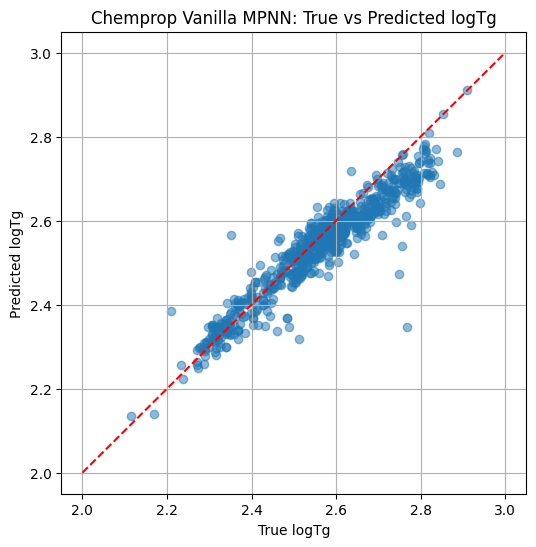

In [246]:
plt.figure(figsize=(6,6))
plt.scatter(df_smiles_train['logTg'], train_preds, alpha=0.5)
plt.plot([2,3], [2,3], color='red', linestyle='--')
plt.xlabel('True logTg')
plt.ylabel('Predicted logTg')
plt.title('Chemprop Vanilla MPNN: True vs Predicted logTg')
plt.grid(True)
plt.show()

In [247]:
# Calculate R² and RMSE
r2 = r2_score(df_smiles_train['logTg'], train_preds)
rmse = root_mean_squared_error(df_smiles_train['logTg'], train_preds)
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.8574
RMSE: 0.0540


# Testing model prediction

In [255]:
df_smiles_test = df_input_w_features[~df_input_w_features['ID'].isin(train_df['Index'])].reset_index(drop=True)

In [256]:
df_smiles_test.shape

(219, 18)

# Create Train/Validation Split for Hyperparameter Optimization

In [ ]:
from sklearn.model_selection import train_test_split

# Create train/validation split (80/20) for hyperparameter optimization
train_indices, val_indices = train_test_split(
    range(len(train_data)), 
    test_size=0.2, 
    random_state=42,
    stratify=None  # Can't stratify regression targets easily
)

# Create separate datasets
train_data_split = [train_data[i] for i in train_indices]
val_data_split = [train_data[i] for i in val_indices]

# Create MoleculeDatasets
train_dset_split = data.MoleculeDataset(train_data_split, featurizer)
val_dset_split = data.MoleculeDataset(val_data_split, featurizer)

# Apply same normalization as original dataset
train_dset_split.Y = scaler.transform(train_dset_split.Y)
val_dset_split.Y = scaler.transform(val_dset_split.Y)

# Apply X_d scaling if it exists
if extra_datapoint_descriptors_scaler is not None:
    if train_dset_split.X_d is not None:
        train_dset_split.X_d = extra_datapoint_descriptors_scaler.transform(train_dset_split.X_d)
    if val_dset_split.X_d is not None:
        val_dset_split.X_d = extra_datapoint_descriptors_scaler.transform(val_dset_split.X_d)

print(f"Training split size: {len(train_data_split)}")
print(f"Validation split size: {len(val_data_split)}")
print(f"Train/Val ratio: {len(train_data_split)/len(val_data_split):.1f}:1")

# Hyperparameter Optimization Options

We now have two approaches for hyperparameter optimization:

1. **K-Fold Cross-Validation**: More robust but computationally expensive
   - Uses `train_model_with_kfold()` function
   - Provides better generalization estimates
   - Recommended for final model selection

2. **Single Train/Val Split**: Faster but less robust
   - Uses traditional `train_model()` function  
   - Good for quick hyperparameter exploration
   - Uses the train/val split created above

**Choose your approach below:**

# Summary of Enhancements

This notebook now includes comprehensive hyperparameter optimization with the following new features:

## New Hyperparameters Added:
1. **Learning Rate**: Log-uniform distribution from 1e-5 to 1e-2
2. **Batch Size**: Choice from [16, 32, 64, 128]
3. **Max Epochs**: Range from 20 to 100 (step of 10)

## Cross-Validation Options:
1. **K-Fold Cross-Validation** (`use_kfold=True`):
   - 5-fold cross-validation for robust evaluation
   - Better generalization estimates
   - More computationally expensive
   - Recommended for final model selection

2. **Single Train/Val Split** (`use_kfold=False`):
   - Traditional 80/20 train/validation split
   - Faster execution
   - Good for hyperparameter exploration
   - Less robust than k-fold

## Key Improvements:
- Systematic hyperparameter search across architecture and training parameters
- Cross-validation for more reliable model selection
- Comprehensive results analysis with visualization
- Final model training with optimal hyperparameters
- Configurable approach selection (k-fold vs single split)

**Usage**: Set `use_kfold = True/False` in the configuration cell to choose your validation approach.

In [257]:
test_smis = df_smiles_test[smiles_column]

In [258]:
test_smis[:5]

0    C=CC(=O)OCC(F)(F)C(F)F
1               C=CC(C)(C)C
2      C=C(CC(=O)OC)C(=O)OC
3                C=CC(=O)CC
4                    C=CSCC
Name: SMILES_clean, dtype: object

In [259]:
test_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis]

In [260]:
test_V_fs = df_smiles_test.loc[:, feat_cols].values

In [ ]:
type(test_V_fs)

numpy.ndarray

In [ ]:
test_V_fs.shape

(683, 7)

In [264]:
test_data = [
    data.MoleculeDatapoint(mol, x_d=X_d) for mol, X_d in zip(test_mols, test_V_fs)
]

In [265]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
test_dset = data.MoleculeDataset(test_data, featurizer)

test_loader = data.build_dataloader(test_dset, shuffle=False)

In [266]:
test_preds = trainer.predict(mpnn, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [267]:
test_preds = np.concatenate(test_preds, axis=0)
df_smiles_test['pred'] = test_preds

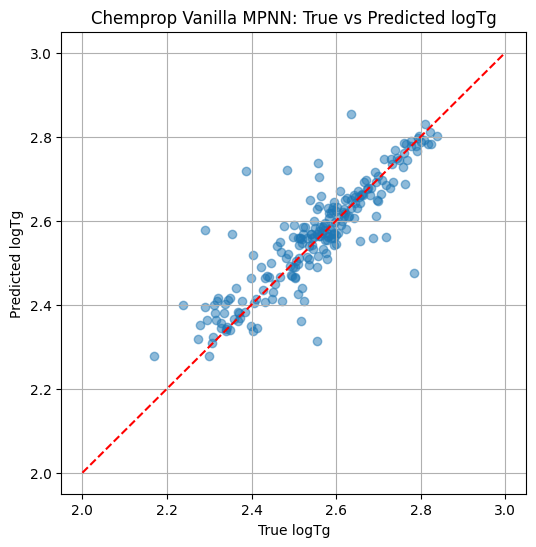

In [268]:
plt.figure(figsize=(6,6))
plt.scatter(df_smiles_test['logTg'], df_smiles_test['pred'], alpha=0.5)
plt.plot([2,3], [2,3], color='red', linestyle='--')
plt.xlabel('True logTg')
plt.ylabel('Predicted logTg')
plt.title('Chemprop Vanilla MPNN: True vs Predicted logTg')
plt.grid(True)
plt.show()

In [269]:
# Calculate R² and RMSE
r2 = r2_score(df_smiles_test['logTg'], df_smiles_test['pred'])
rmse = root_mean_squared_error(df_smiles_test['logTg'], df_smiles_test['pred'])
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.7601
RMSE: 0.0680


In [270]:
# Save the trained model
save_model(PROJECT_ROOT / 'data' / 'processed' /'chemprop_w_features_mpnn_model.pickle', mpnn)

---